# Final Project: Bank Customer Churn Prediction
Yufan Liu - Leo
## Requirements
Those packages are required to start up:
- `Python` 3.11
- `Pandas`
- `Numpy`
- `Matplotlib`

## Purpose

This project predicts：
 - Whether a bank customer will churn (close their account) using classification models.

 
The project aims to:
- Achieve a business goal where the bank can identify at-risk customers so the bank can take proactive retention actions.

This project will construct a complete ML pipeline: data inspection, preprocessing, model training, evaluation, and comparison of multiple classifiers.


## Dataset

Use `Churn_Modelling.csv`.

This is a **synthetic dataset** of 10,000 bank customers, designed to simulate a real-world churn prediction task. Each row represents one customer at a static snapshot in time (no temporal dimension). The target variable is `Exited` (1 = churned, 0 = stayed).

Columns:
- `RowNumber`, `CustomerId`: Unique identifiers (to be dropped for modeling)
- `Surname`: Customer's surname (identifier, to be dropped)
- `CreditScore`: Credit score
- `Geography`: Customers' country (France, Spain, Germany)
- `Gender`: Male / Female
- `Age`: Customer age
- `Tenure`: Years with the bank
- `Balance`: Account balance
- `NumOfProducts`: Number of bank products used
- `HasCrCard`: Has credit card (0/1)
- `IsActiveMember`: Active member (0/1)
- `EstimatedSalary`: Estimated annual salary
- `Exited`: Target variable (1 = churned)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 1: EDA

### 1.1 Data Quality Check

In [3]:
# Missing value detection
missing = df.isnull().sum()
print('Missing values: ')
print(missing.sum())

# Duplicated rows detection
print('\nDuplicated rows:')
print(df.duplicated().sum())

# Outliers detection
rules = {
    'CreditScore':     lambda x: (x < 300) | (x > 850),
    'Age':             lambda x: (x < 18)  | (x > 100),
    'Tenure':          lambda x: (x < 0)   | (x > 10),
    'Balance':         lambda x: x < 0,
    'NumOfProducts':   lambda x: (x < 1)   | (x > 4),
    'EstimatedSalary': lambda x: x < 0,
    'HasCrCard':       lambda x: ~x.isin([0, 1]),
    'IsActiveMember':  lambda x: ~x.isin([0, 1]),
}
print('\nOutliers:')
total_violations = 0
for col, rule in rules.items():
    if col in df.columns:
        n = rule(df[col]).sum()
        total_violations += n
        print(f'{col:20s}: {n:4d} ({n/len(df):.2%})')
print(f'{"Total count":20s}: {total_violations:4d}')


Missing values: 
0

Duplicated rows:
0

Outliers:
CreditScore         :    0 (0.00%)
Age                 :    0 (0.00%)
Tenure              :    0 (0.00%)
Balance             :    0 (0.00%)
NumOfProducts       :    0 (0.00%)
EstimatedSalary     :    0 (0.00%)
HasCrCard           :    0 (0.00%)
IsActiveMember      :    0 (0.00%)
Total count         :    0


### 1.2 Single Feature Distribution Analysis

In [4]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

# Mean, Median, Std
num_stats = df[num_cols].agg(['mean', 'median', 'std']).T.round(2)
num_stats['skewness'] = num_stats['mean'] > num_stats['median']  # True = right skewed
print('Mean, Median, Std:')
print(num_stats)

# The frequency of value in categories
cat_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
print('\nCategory Frequency: ')
for col in cat_cols:
    vc = (df[col].value_counts(normalize=True) * 100).round(1)
    print(f'{col}:')
    for val, pct in vc.items():
        print(f'  {val}: {pct}')
        
# Churn rate group by category
print('\nCategory Churn Rate: ')
for col in cat_cols:
    summary = pd.DataFrame({
        'Count': df[col].value_counts().sort_index(),
        'Churn%': df.groupby(col)['Exited'].mean().apply(lambda x: f'{x:.2%}')
    })
    print(summary.to_string())


Mean, Median, Std:
                      mean     median       std  skewness
CreditScore         650.53     652.00     96.65     False
Age                  38.92      37.00     10.49      True
Tenure                5.01       5.00      2.89      True
Balance           76485.89   97198.54  62397.41     False
NumOfProducts         1.53       1.00      0.58      True
HasCrCard             0.71       1.00      0.46     False
IsActiveMember        0.52       1.00      0.50     False
EstimatedSalary  100090.24  100193.92  57510.49     False

Category Frequency: 
Geography:
  France: 50.1
  Germany: 25.1
  Spain: 24.8
Gender:
  Male: 54.6
  Female: 45.4
NumOfProducts:
  1: 50.8
  2: 45.9
  3: 2.7
  4: 0.6
HasCrCard:
  1: 70.6
  0: 29.4
IsActiveMember:
  1: 51.5
  0: 48.5

Category Churn Rate: 
           Count  Churn%
Geography               
France      5014  16.15%
Germany     2509  32.44%
Spain       2477  16.67%
        Count  Churn%
Gender               
Female   4543  25.07%
Male     54

### 1.3 Multi Feature Relationship Analysis

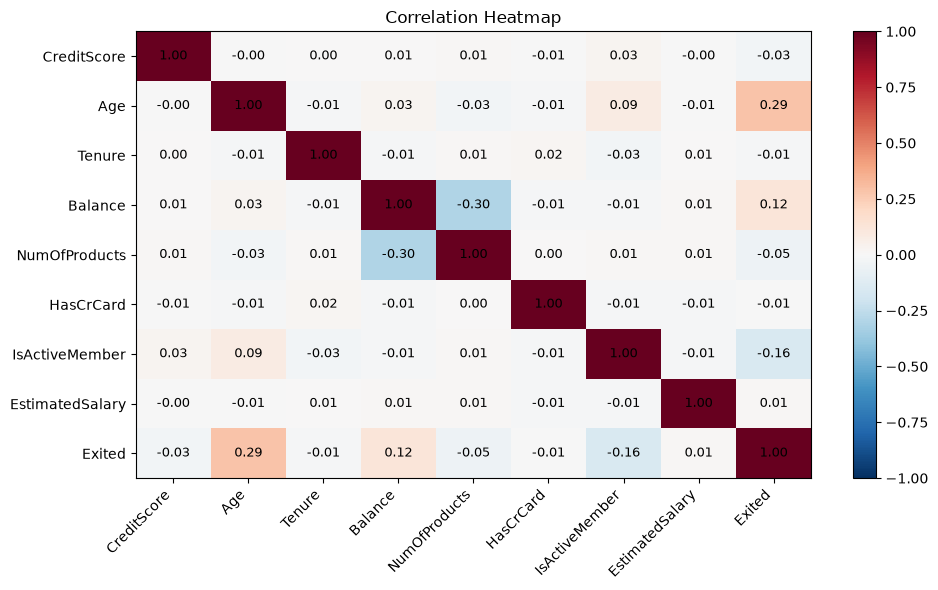

In [5]:
# Feature correlation heatmap
corr = df.select_dtypes(include=np.number).drop(columns=['RowNumber','CustomerId']).corr()
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### EDA Summary

**Data Quality**: 10,000 rows, no missing/duplicates. 


**Data Frequency**: NumOfProducts=3 (2.7%) and 4 (0.6%) are low-frequency maybe should be considered to merge.

**Target & Metrics**: 20.4% churn — moderate skewness. Prioritize recall/precision/F1 over accuracy.

**Key Findings**:

| Feature | Pattern |
|---------|---------|
| NumOfProducts | 1→27.7%, 2→7.6%, 3→82.7%, 4→100%. Extreme churn at ≥3, though rare. |
| Geography | Germany 32.4% vs France 16.2%, Spain 16.7%. |
| IsActiveMember | Inactive 26.9% vs active 14.3%. |
| Gender | Female 25.1% vs male 16.5%. |
| Age | Strongest linear predictor (r=0.28). Mean 39, range 18–92. |
| Balance | 36% zero-balance; churn differs notably between groups. |
| HasCrCard | Churn nearly identical (≈20%), no predictive value. |

**Correlation Heatmap**: Most numerical features show weak linear correlation with Exited, so tree-based / boosting models was expected to perform well.


## Step 2: Data Preprocessing & Feature Engineering

Data cleaning, engineer features, build preprocessing pipeline for modeling.


### 2.1 Drop Non-Informative Columns

`RowNumber`, `CustomerId`, `Surname` are identifiers with no predictive value.

In [6]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(f'Shape after dropping: {df.shape}')

Shape after dropping: (10000, 11)


### 2.2 Train/Test Split

Stratified split (80/20) to preserve same churn rate in test and train set.

In [7]:
X = df.drop('Exited', axis=1)
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}')

Train size: 8000, Test size: 2000
Train churn rate: 0.204, Test churn rate: 0.203


### 2.3 Feature Engineering

- **NumOfProducts**: Merge 4→3 (The frequency was too low, so merged into 1 value)
- **BalanceToSalary**: Balance / (EstimatedSalary + 1) (captures salary retention ratio)
- **ActivityScore**: IsActiveMember × NumOfProducts (captures active × products interaction)
- **NewCustomer**: Tenure ≤ 2 binary flag (marks recently joined customers)

In [8]:
# Feature Engineering
for dataset in [X_train, X_test]:
    dataset['NumOfProducts'] = dataset['NumOfProducts'].replace(4, 3) # Merge rare category
    dataset['BalanceToSalary'] = dataset['Balance'] / (dataset['EstimatedSalary'] + 1) # Salary retention
    dataset['ActivityScore'] = dataset['IsActiveMember'] * dataset['NumOfProducts'] # Active & products relationship
    dataset['NewCustomer'] = (dataset['Tenure'] <= 2).astype(int) # Identify new customers

# Verify new features
X_train[['NumOfProducts','BalanceToSalary','ActivityScore','NewCustomer']].head()


,NumOfProducts,BalanceToSalary,ActivityScore,NewCustomer
493,1,0.000000,0,0
6839,2,8.902262,2,0
170,1,0.793289,0,0
4958,2,61.408490,0,0
4271,2,0.000000,2,0


### 2.4 Preprocessing Pipeline

- **Numeric**: Impute (median) → StandardScaler
- **Categorical**: Impute (most_frequent) → OneHotEncoder(drop='first')

The result will be construct into one dataset, the result will be checked after preprocessing.

Note: `drop='first'` avoids dummy variable trap for Logistic Regression, avoid data leakage.

In [9]:
# Preprocessing Pipeline
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'BalanceToSalary', 'ActivityScore']
categorical_features = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'NewCustomer']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after encoding
num_names = numeric_features
cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = list(num_names) + list(cat_names)

print(f'Train: {X_train_processed.shape}, Test: {X_test_processed.shape}, Features: {len(all_features)}')


Train: (8000, 15), Test: (2000, 15), Features: 15


## Step 3: Evaluation Framework

### 3.1 Business Metric Selection

In churn prediction, **not all errors are equal**:

| Prediction | Business Meaning | Cost |
|---|---|---|
| **TP** (catch churner) | Opportunity to save customer | -- |
| **FN** (miss churner) | Customer loss | High |
| **FP** (false alarm) | Manuel retention offer | Low |
| **TN** (everything's fine) | Another day of sun | -- |

Therefore, from the analysis of business meaning and cost, we can select **Recall** as the primary metric, the ideal model should maximize recall to catch as many churners as possible.

**Other three evaluation metrics used:**
- **Accuracy**: Overall correctness (baseline reference)
- **Precision**: Of predicted churners, how many actually churned?
- **AUC-ROC**: Model ranking ability -- distinguishes churners from non-churners

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

def evaluate_model(y_true, y_pred, y_prob=None, model_name=""):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }
    print(f"\n{model_name}")
    for k, v in metrics.items():
        if v is not None:
            print(f"  {k:12s}: {v:.4f}")
    return metrics

print("Done")

Done


## Step 4: Model Training & Comparison

### 4.1 Model construction and training

Model:
- `Logistic Regression`: The representation of Linear model family, used as baseline.
- `Random Forest1`: The representation of bagging strategy.
- `XGBoost`: The representation of gradient boosting strategy.

Workflow:
- **Optimization**: `RandomSearchCV` used recall as criteria, aim to maximize churner detection
- **Input**: Preprocessed arrays from Step2 (X_train_processed and X_test_processed)
- **Output**: metrics + confusion matrix heatmap (per model)


Logistic Regression
  Accuracy    : 0.8400
  Precision   : 0.7005
  Recall      : 0.3735
  AUC-ROC     : 0.8280


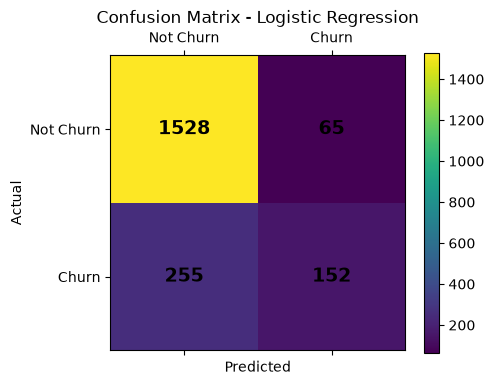

In [11]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)
y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]
metrics_lr = evaluate_model(y_test, y_pred_lr, y_prob_lr, model_name="Logistic Regression")

# Evaluation
fig, ax = plt.subplots(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
im = ax.matshow(cm_lr)
for (i, j), val in np.ndenumerate(cm_lr):
    ax.text(j, i, str(val), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Churn', 'Churn']); ax.set_yticklabels(['Not Churn', 'Churn'])
ax.set_title('Confusion Matrix - Logistic Regression')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.colorbar(im)
plt.tight_layout()
plt.show()


Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Random Forest
  Accuracy    : 0.7890
  Precision   : 0.4878
  Recall      : 0.7346
  AUC-ROC     : 0.8494


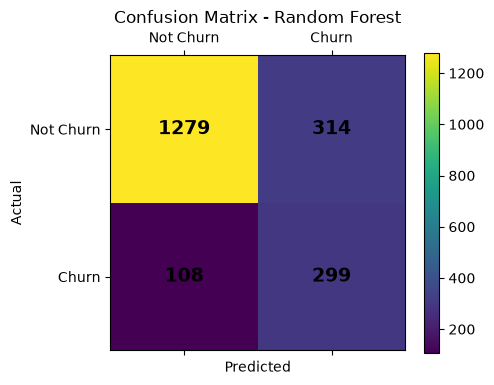

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_search = GridSearchCV(rf_base, rf_param_grid, cv=3, scoring='recall', n_jobs=-1) # GridSearchCV cv=3
rf_search.fit(X_train_processed, y_train)
rf_model = rf_search.best_estimator_
print(f"Best params: {rf_search.best_params_}")
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]
metrics_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf, model_name="Random Forest")

# Evaluation
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
im = ax.matshow(cm_rf)
for (i, j), val in np.ndenumerate(cm_rf):
    ax.text(j, i, str(val), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Churn', 'Churn']); ax.set_yticklabels(['Not Churn', 'Churn'])
ax.set_title('Confusion Matrix - Random Forest')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.colorbar(im)

plt.tight_layout()
plt.show()


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

XGBoost
  Accuracy    : 0.8040
  Precision   : 0.5132
  Recall      : 0.7174
  AUC-ROC     : 0.8579


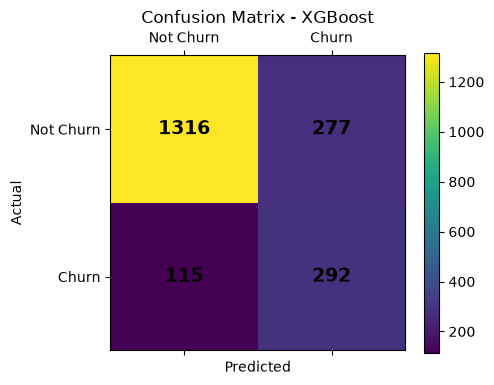

In [13]:
from xgboost import XGBClassifier

# XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# The data was imbalance, so we need to adjust the scale_pos_weight parameter to balance the data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, scale_pos_weight=scale_pos)
xgb_search = GridSearchCV(xgb_base, xgb_param_grid, cv=3, scoring='recall', n_jobs=-1)
xgb_search.fit(X_train_processed, y_train)
xgb_model = xgb_search.best_estimator_
print(f"Best params: {xgb_search.best_params_}")
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]
metrics_xgb = evaluate_model(y_test, y_pred_xgb, y_prob_xgb, model_name="XGBoost")

# Evaluation (Confusion Matrix and Heatmap)
fig, ax = plt.subplots(figsize=(5, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
im = ax.matshow(cm_xgb)
for (i, j), val in np.ndenumerate(cm_xgb):
    ax.text(j, i, str(val), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Churn', 'Churn']); ax.set_yticklabels(['Not Churn', 'Churn'])
ax.set_title('Confusion Matrix - XGBoost')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.colorbar(im)

plt.tight_layout()
plt.show()


## Step 5: Model Comparison

### 5.1 Feature Analysis
- Feature importance (from RandomForest and XGBoost, selected top-10 features for display)
- Ablation test (Test if the new feature constructed in Feature Engineering is useful (BalanceToSalary / ActivityScore / NewCustomer))

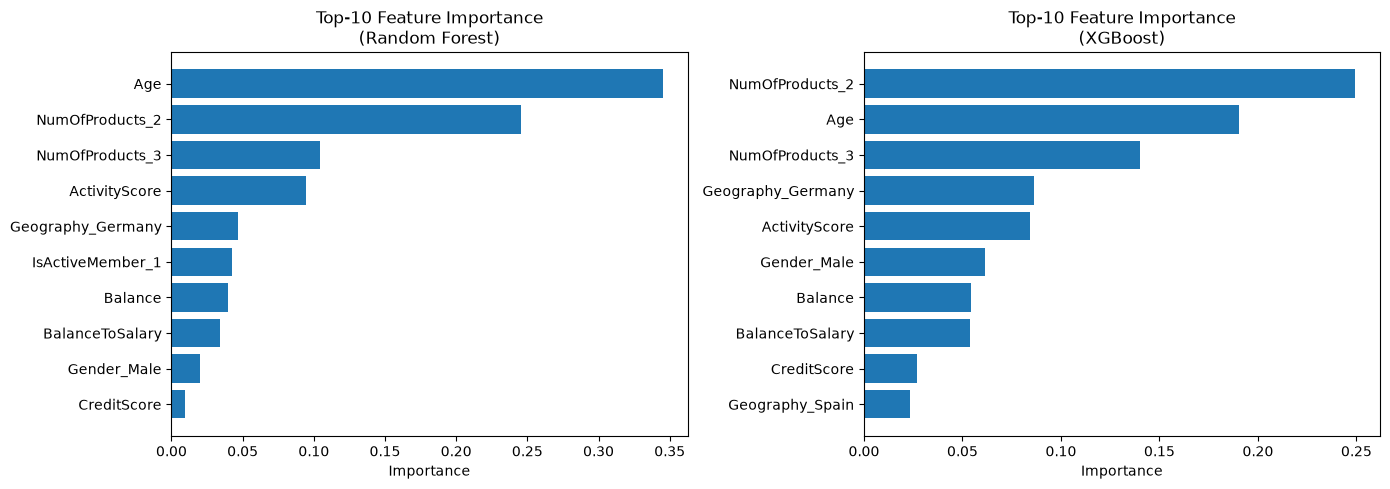

In [14]:
# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
rf_importances = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
axes[0].barh(rf_importances.index[::-1], rf_importances.values[::-1])
axes[0].set_title('Top-10 Feature Importance\n(Random Forest)', fontsize=12)
axes[0].set_xlabel('Importance')

# XGBoost
xgb_importances = pd.Series(xgb_model.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
axes[1].barh(xgb_importances.index[::-1], xgb_importances.values[::-1])
axes[1].set_title('Top-10 Feature Importance\n(XGBoost)', fontsize=12)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [15]:
# Ablation Test

# Random Forest + All Features (Baseline)
rf_full = RandomForestClassifier(**rf_model.get_params())
rf_full.fit(X_train_processed, y_train)
y_pred_full = rf_full.predict(X_test_processed)
recall_full = recall_score(y_test, y_pred_full)

# Remove BalanceToSalary
cols_no_bal = [c for c in all_features if c != 'BalanceToSalary']
idx_no_bal = [all_features.index(c) for c in cols_no_bal]
rf_no_bal = RandomForestClassifier(**rf_model.get_params())
rf_no_bal.fit(X_train_processed[:, idx_no_bal], y_train)
y_pred_no_bal = rf_no_bal.predict(X_test_processed[:, idx_no_bal])
recall_no_bal = recall_score(y_test, y_pred_no_bal)

# remove ActivityScore
cols_no_act = [c for c in all_features if c != 'ActivityScore']
idx_no_act = [all_features.index(c) for c in cols_no_act]
rf_no_act = RandomForestClassifier(**rf_model.get_params())
rf_no_act.fit(X_train_processed[:, idx_no_act], y_train)
y_pred_no_act = rf_no_act.predict(X_test_processed[:, idx_no_act])
recall_no_act = recall_score(y_test, y_pred_no_act)

# Remove NewCustomer
cols_no_new = [c for c in all_features if c != 'NewCustomer_1']
idx_no_new = [all_features.index(c) for c in cols_no_new]
rf_no_new = RandomForestClassifier(**rf_model.get_params())
rf_no_new.fit(X_train_processed[:, idx_no_new], y_train)
y_pred_no_new = rf_no_new.predict(X_test_processed[:, idx_no_new])
recall_no_new = recall_score(y_test, y_pred_no_new)

# Remove everything
cols_all = [c for c in all_features if c not in ['BalanceToSalary', 'ActivityScore', 'NewCustomer_1']]
idx_all = [all_features.index(c) for c in cols_all]
rf_all = RandomForestClassifier(**rf_model.get_params())
rf_all.fit(X_train_processed[:, idx_all], y_train)
y_pred_all = rf_all.predict(X_test_processed[:, idx_all])
recall_all = recall_score(y_test, y_pred_all)

print(f"{' ':<20} {'Recall':>10}")
print(f"{'All features':<20} {recall_full:>10.4f}")
print(f"{'No BalanceToSalary':<20} {recall_no_bal:>10.4f}")
print(f"{'No ActivityScore':<20} {recall_no_act:>10.4f}")
print(f"{'No NewCustomer':<20} {recall_no_new:>10.4f}")
print(f"{'No new features':<20} {recall_all:>10.4f}")


                         Recall
All features             0.7346
No BalanceToSalary       0.7199
No ActivityScore         0.7273
No NewCustomer           0.7322
No new features          0.7297


### 5.2 Prediction Metrics
- Accuracy, Precision, Recall, AUC-ROC metrics comparison table
- ROC curve comparison
- Logistic regression coefficients

In [16]:
# 5.1 Performance Metrics Comparison Table
metrics_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Random Forest': metrics_rf,
    'XGBoost': metrics_xgb
}).T
metrics_df.index.name = 'Model'

display(metrics_df.round(4))

,Accuracy,Precision,Recall,AUC-ROC
Model,,,,
Logistic Regression,0.840,0.7005,0.3735,0.8280
Random Forest,0.789,0.4878,0.7346,0.8494
XGBoost,0.804,0.5132,0.7174,0.8579


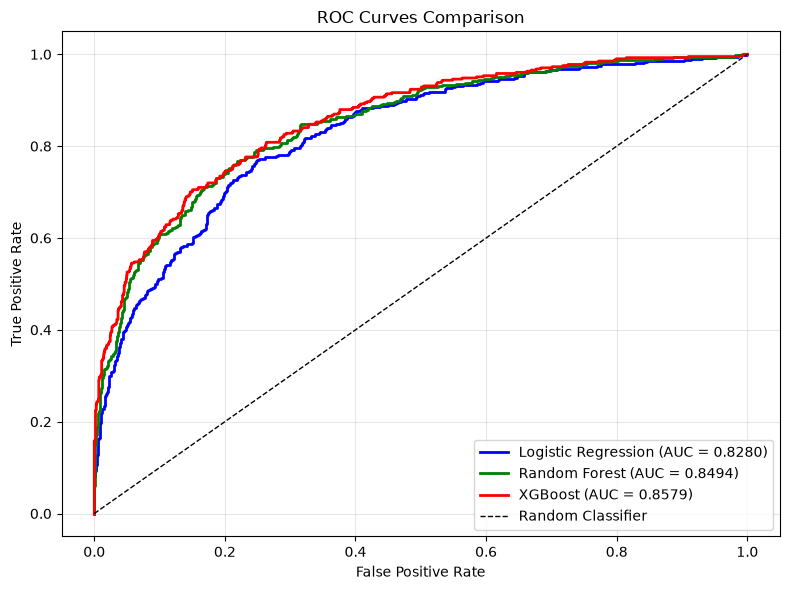

In [17]:
# 5.2 ROC Curve Comparison
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, y_prob, color in [('Logistic Regression', y_prob_lr, 'blue'),
                              ('Random Forest', y_prob_rf, 'green'),
                              ('XGBoost', y_prob_xgb, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 5.3 Logistic Regression Coefficients - Top 10
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': lr_model.coef_[0]
})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoefficient', ascending=False).head(10)
coef_df['Direction'] = coef_df['Coefficient'].apply(lambda x: '+ Churn' if x > 0 else '- Retain')
coef_df = coef_df[['Feature', 'Coefficient', 'Direction']].reset_index(drop=True)

display(coef_df.round({'Coefficient': 4}))

,Feature,Coefficient,Direction
0,NumOfProducts_3,2.5644,+ Churn
1,NumOfProducts_2,-1.6168,- Retain
2,IsActiveMember_1,-1.2122,- Retain
3,Geography_Germany,0.9154,+ Churn
4,Age,0.7525,+ Churn
5,Gender_Male,-0.5359,- Retain
6,BalanceToSalary,0.2083,+ Churn
7,ActivityScore,0.1077,+ Churn
8,HasCrCard_1,-0.1017,- Retain
9,Tenure,-0.0859,- Retain
